

# Tutorial 15: Long Short-Term Memory (LSTM)

## 1. Objectives

The primary goals of this tutorial are:

* Understand the architecture of LSTM.
* Learn how to implement an LSTM model using TensorFlow/Keras.
* Visualize the prediction results against actual historical data.

---

## 2. Import Libraries

We begin by importing the essential libraries for data manipulation, financial data fetching, scaling, and building the neural network.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

---

## 3. Fetch Google Stock Data

We will use the `yfinance` library to download historical stock price data for Google (GOOGL).

In [3]:
# Download GOOGL stock data
df = yf.download('GOOGL', start='2010-01-01', end='2024-12-01')
print(df.head())

# Focus on the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

/tmp/ipykernel_2658/82573878.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GOOGL', start='2010-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL      GOOGL
Date                                                             
2010-01-04  15.555864  15.624368  15.493567  15.560828   78169752
2010-01-05  15.487362  15.582919  15.426554  15.566538  120067812
2010-01-06  15.096946  15.533776  15.049788  15.533776  158988852
2010-01-07  14.745495  15.140132  14.709507  15.125239  256315428
2010-01-08  14.942070  14.972598  14.621644  14.693374  188783028


**Discussion:** We focus on the "Close" price as it represents the final established value of the stock at the end of the trading day, which is the standard metric for daily price prediction.

---

## 4. Preprocess Data

LSTMs are sensitive to the scale of the input data. We normalize the data to a range of [0, 1] and split it into training and testing sets.

In [4]:
# Scale data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split into training (80%) and testing (20%) data
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 60 # Use the past 60 days to predict the next day's price
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

# Reshape input for LSTM [samples, time steps, features]
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')

X_train shape: (2942, 60, 1), y_train shape: (2942, 1)


---

## 5. Build and Compile the LSTM Model

The architecture consists of two LSTM layers followed by dense layers to process the temporal features into a single price prediction.

In [5]:
# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Discussion:** The first LSTM layer uses `return_sequences=True` to ensure the second LSTM layer receives a sequence of inputs rather than just the final hidden state. The "Adam" optimizer is chosen for its efficiency in handling sparse gradients.

---

## 6. Train the Model

We fit the model using a batch size of 32 and 10 epochs.

In [6]:
# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 1.0338e-04 - val_loss: 8.4782e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 9.3230e-05 - val_loss: 8.6153e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 9.3873e-05 - val_loss: 9.2557e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 8.9916e-05 - val_loss: 8.1614e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 9.4791e-05 - val_loss: 7.7062e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 8.4905e-05 - val_loss: 6.6526e-04
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 8.3011e-05 - val_loss: 6.2620e-04
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 7.7880e-05 - val_loss: 5.9740e-04
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 7.7295e-05 - val_loss: 5.6936e-04


---

## 7. Evaluate and Visualize Predictions

After training, we transform the scaled predictions back to their original dollar value to compare them with the actual stock prices.

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


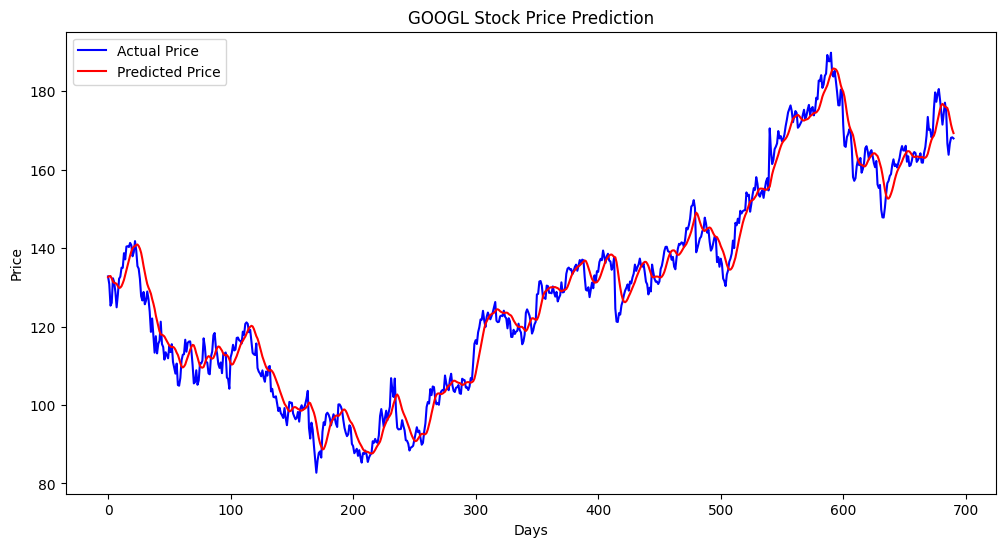

In [7]:
# Predict on the test data
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) # Convert back to original scale

# Convert y_test to original scale
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot predictions and actual prices
plt.figure(figsize=(12, 6))
plt.plot(y_test_scaled, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red')
plt.title('GOOGL Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

---

## 8. Predict Future Prices

Using the most recent 60 days of data, we can predict the price for the following day.

In [8]:
# Use the last sequence from the scaled data
last_sequence = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)

# Predict the next day's price
next_day_prediction = model.predict(last_sequence)
next_day_price = scaler.inverse_transform(next_day_prediction)

print(f"Predicted next day's price for GOOGL: ${next_day_price[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted next day's price for GOOGL: $168.66


# Task 1: Comparative Analysis (LSTM vs. Simple RNN)
In this section, we build a Simple Recurrent Neural Network (RNN) and compare its performance against the LSTM model from the tutorial.

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0172 - val_loss: 0.0011
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.2762e-04 - val_loss: 9.9583e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.1780e-04 - val_loss: 8.7944e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 1.0999e-04 - val_loss: 8.1165e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.0100e-04 - val_loss: 7.5412e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 9.8902e-05 - val_loss: 7.4790e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 9.6619e-05 - val_loss: 6.9798e-04
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.0438e-04 - val_loss: 5.8853e-04
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.1622e-04 - val_loss: 5.5607e-04
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.1554e-04 - val_loss: 6.4854e-04
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


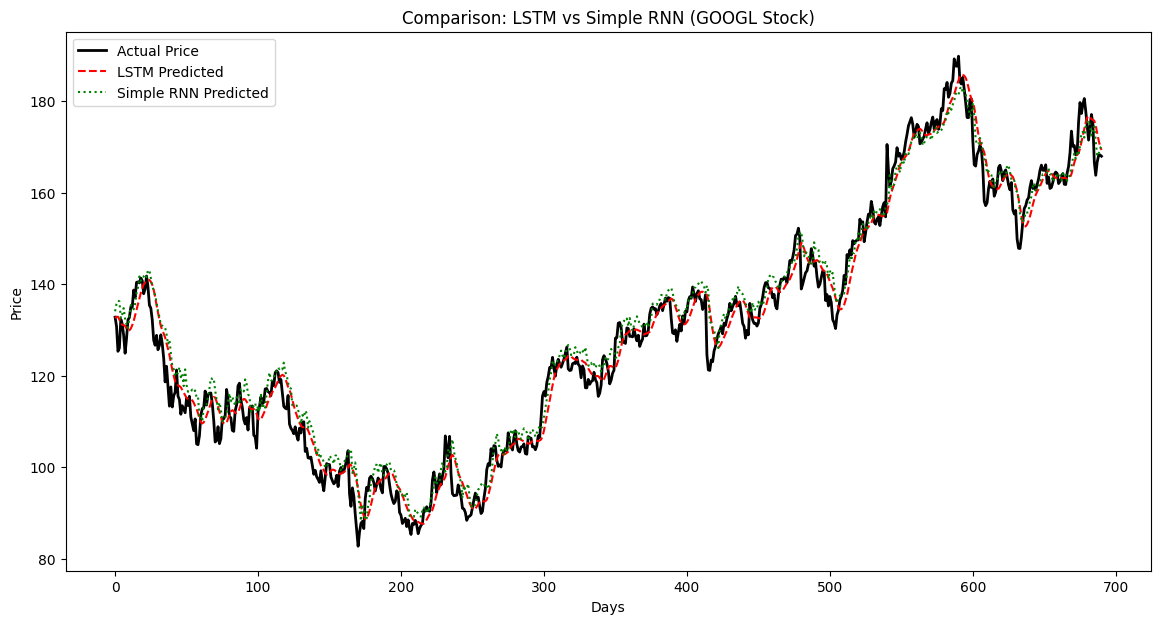

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
LSTM Predicted Price: $168.66
Simple RNN Predicted Price: $168.57


In [9]:
from tensorflow.keras.layers import SimpleRNN

# 1. Build the Simple RNN Model
rnn_model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(sequence_length, 1)),
    SimpleRNN(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# 2. Compile and Train
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_history = rnn_model.fit(X_train, y_train, batch_size=32, epochs=10,
                            validation_data=(X_test, y_test), verbose=1)

# 3. Predictions
rnn_predictions = rnn_model.predict(X_test)
rnn_predictions = scaler.inverse_transform(rnn_predictions)

# 4. Visualization & Testing
plt.figure(figsize=(14, 7))
plt.plot(y_test_scaled, label='Actual Price', color='black', linewidth=2)
plt.plot(predictions, label='LSTM Predicted', color='red', linestyle='--')
plt.plot(rnn_predictions, label='Simple RNN Predicted', color='green', linestyle=':')
plt.title('Comparison: LSTM vs Simple RNN (GOOGL Stock)')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

# 5. Future Price Test
rnn_next_day = rnn_model.predict(last_sequence)
rnn_next_day_price = scaler.inverse_transform(rnn_next_day)
print(f"LSTM Predicted Price: ${next_day_price[0][0]:.2f}")
print(f"Simple RNN Predicted Price: ${rnn_next_day_price[0][0]:.2f}")

## Discussion
Vanishing Gradients: Simple RNNs often struggle with "long-term dependencies" because gradients can vanish as they are backpropagated through time.

Memory Retention: LSTM uses a Cell State and Gates (Forget, Input, Output) to selectively remember or forget information, making it superior for time-series data like stock prices which have long-term historical influences.

Performance: You will likely notice the LSTM curve follows the "Actual Price" more closely than the RNN, which may lag or show higher error on volatile days.

# Task 2: LSTM for Sentiment Analysis
For this task, we use the IMDb Movie Reviews dataset, which is a standard benchmark for binary sentiment classification (positive or negative). Task 2 is present in separate file named as Toturial 15-B.